## Load Trained Model and Data

Loading the final XGBoost (Poisson objective) model and the full hexagon dataset (1,353 hexagons, all predictor features), to run SHAP analysis for feature importance (RQ1). The full dataset is used rather than the train/test modeling split from notebook 07 since SHAP explains model behaviour across Berlin rather than testing generalization.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import shap
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

gdf_full = gpd.read_file('../data/processed/berlin_h3_res8_with_all_features.geojson')
xgb_model = joblib.load('../outputs/models/xgb_poisson_final.pkl')

predictors = ['transit_stops_500m', 'rail_stations_800m', 'shops_500m', 
              'offices_500m', 'food_500m', 'universities_800m', 
              'coworking_500m', 'green_spaces_800m', 'culture_700m', 
              'population_density_per_km2']

print(f"Data shape: {gdf_full.shape}")

Data shape: (1353, 14)


## Compute SHAP Values

Using SHAP (SHapley Additive ExPlanations) to break down how much each feature contributes to the model's predictions for every hexagon. Computed on the full dataset since this explains model behavior rather than testing generalization. TreeExplainer is used since

In [2]:
X_full = gdf_full[predictors]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_full)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1353, 10)


## SHAP Summary Plot

Visualizing overall feature importance and effect direction. Features are ranked by their average impact on predictions, with color showing whether high or low feature values push predictions up or down.

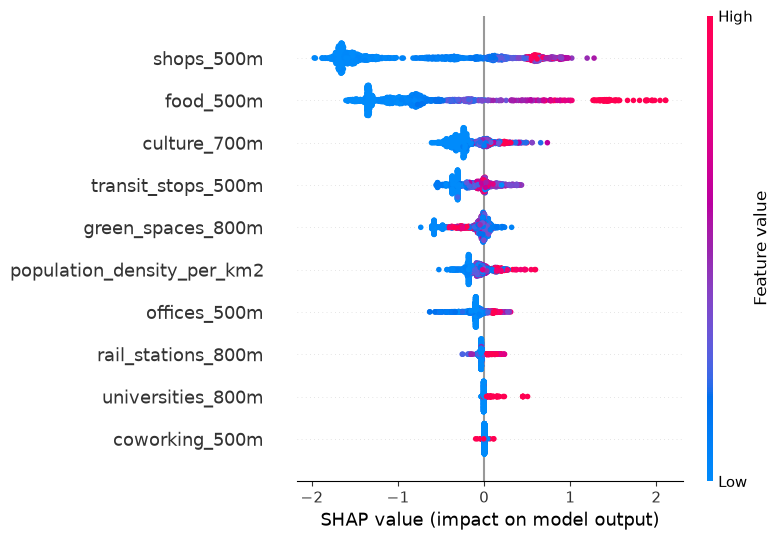

In [3]:
shap.summary_plot(shap_values, X_full, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

The summary plot shows shops_500m and food_500m as the two dominant predictors consistent with the mean absolute SHAP 
values reported below. Higher densities of nearby shops and food venues push predictions toward more popular cafés. culture_700m and transit_stops_500m follow at a lower level of importance and the remaining features (offices, rail stations, universities, coworking spaces) contribute only marginally to individual predictions.

## Mean Absolute SHAP Value (Feature Importance Ranking)

Simplified feature importance ranking based on the average magnitude of each feature's SHAP value across all hexagons regardless of direction.

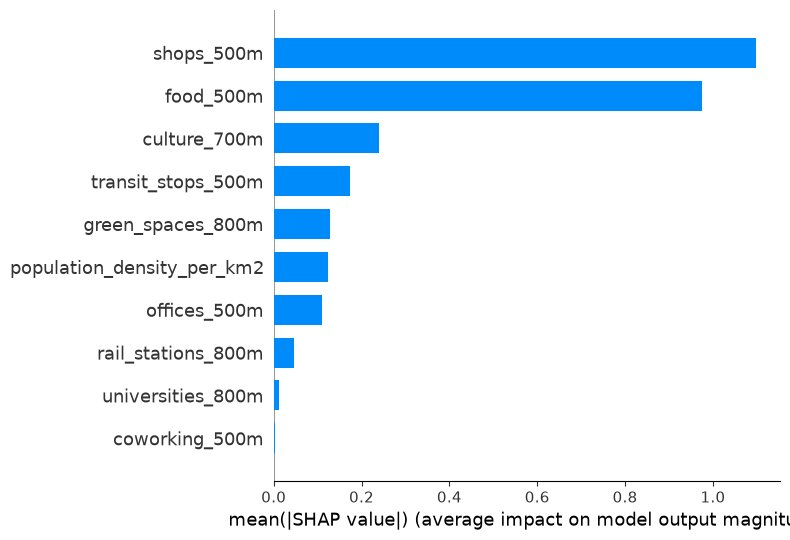

                      feature  mean_abs_shap
2                  shops_500m       1.097740
4                   food_500m       0.975377
8                culture_700m       0.240107
0          transit_stops_500m       0.174405
7           green_spaces_800m       0.128141
9  population_density_per_km2       0.122601
3                offices_500m       0.110618
1          rail_stations_800m       0.045538
5           universities_800m       0.011200
6              coworking_500m       0.003619


In [4]:
shap.summary_plot(shap_values, X_full, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap = pd.DataFrame({
    'feature': predictors,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

mean_abs_shap.to_csv('../outputs/tables/shap_feature_importance.csv', index=False)
print(mean_abs_shap)

Shops_500m (1.097) and food_500m (0.980) account for  two-thirds of total feature importance. Given the correlation flagged between these two features during EDA (r = 0.92, VIF > 10), the split between them is less meaningful than their combined weight. culture_700m (0.237) is at a distant third ahead of transit_stops_500m (0.176). green_spaces_800m, population_density, and offices_500m are close together between 0.11 and 0.13. universities_800m and coworking_500m contribute almost nothing.

##  SHAP Waterfall Plot (Example Hexagon)

Using one hexagon with a high predicted café count as an example of how SHAP valies combine to produce a single prediction

Selected hexagon index: 1293
Predicted popular_cafe_count: 18.699
Actual popular_cafe_count: 21


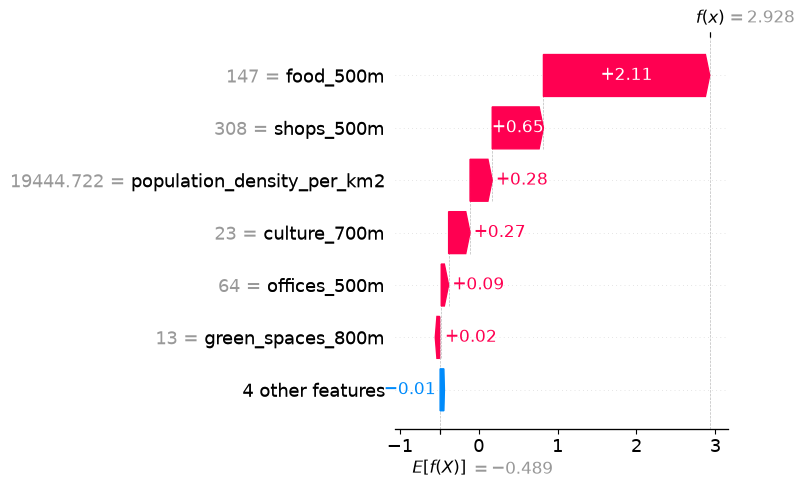

In [5]:

predictions_full = xgb_model.predict(X_full)

top_idx = np.argmax(predictions_full)

print(f"Selected hexagon index: {top_idx}")
print(f"Predicted popular_cafe_count: {predictions_full[top_idx]:.3f}")
print(f"Actual popular_cafe_count: {gdf_full.iloc[top_idx]['popular_cafe_count']}")

explanation = shap.Explanation(
    values=shap_values[top_idx],
    base_values=explainer.expected_value,
    data=X_full.iloc[top_idx],
    feature_names=predictors
)
plt.figure(figsize=(10, 6))

shap.plots.waterfall(explanation, max_display=7, show=False)

plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_example.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

For this hexagon, the model predicts 18.699 cafés against an actual value of 21. food_500m is the main driver contributing +2.11 - more than three times the effect of any other feature - followed by shops_500m at +0.65. population_density_per_km2 and culture_700m contribute approx +0.28 and +0.27 respectively with the remaining features adding only small amounts.

The base value of -0.489 shows the dataset's zero-inflation since most hexagons contain no popular café at all - so the average log-prediction starts below zero before any features are applied.

This example shows that local effects can differ from aggregate importance: here, food_500moutweighs shops_500m by more than 3 to 1, whereas across all hexagons the two features are muchcloser (1.097 vs 0.980). Global feature importance summarises a distribution of local effects - it isn't a fixed rule that applies to every hexagon.

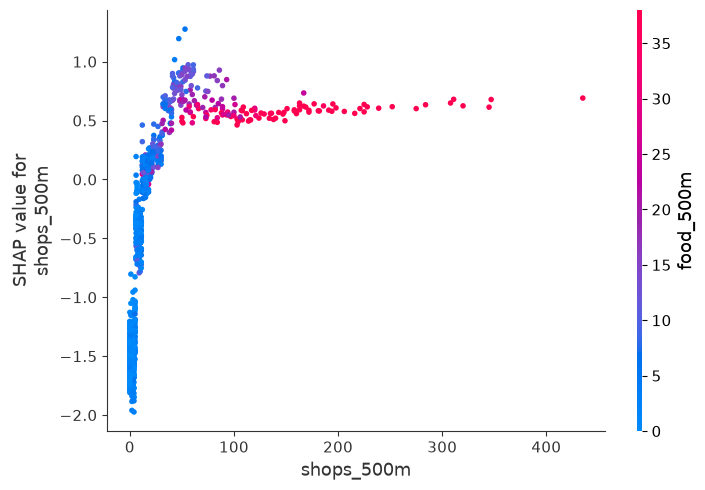

In [6]:
shap.dependence_plot(
    'shops_500m', shap_values, X_full, 
    interaction_index='food_500m', show=False
)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_dependence_shops_food.png', dpi=150, bbox_inches='tight')
plt.show()

This dependence plot shows a steep and non-linear relationship between shops_500m and its SHAP value. Below about 30 nearby shops, the effect on predicted café density is strongly negative. Above about 100, the effect levels off around 0.6-0.7 - extra shops stop making much difference once an area is already commercial.

The colour (food_500m) tracks shops_500m closely across the whole plot, with little mixing at any given x-value. This confirms what the r = 0.92 correlation already suggested - shop density and food density rise and fall together, so this plot can't isolate one feature's effect from the other. It's better to read the two as one combined signal of commercial density instead of two separate predictors.

In [7]:
# confirm whether SHAP values are on the log scale 

raw_sum = shap_values[top_idx].sum() + explainer.expected_value
print(f"Sum of SHAP values + base value (raw/log scale): {raw_sum:.3f}")
print(f"exp() of that sum: {np.exp(raw_sum):.3f}")
print(f"Model's actual predicted count for this hexagon: {predictions_full[top_idx]:.3f}")

Sum of SHAP values + base value (raw/log scale): 2.928
exp() of that sum: 18.699
Model's actual predicted count for this hexagon: 18.699


##  Note on SHAP Value Scale

XGBoost's Poisson objective uses a log scale. The model's raw output is the log of the expected café count, not the count itself. SHAP values 
from TreeExplainer are computed on this same raw scale. This has been verified in the cell above The sum of its SHAP values plus the base value equals 2.928, and exp(2.928) = 18.699, matching the model's actual predicted count exactly.

## Summary: Answering RQ1

SHAP analysis identifies commercial density as the strongest predictor of popular café density - shops_500m and food_500m together account for about two-thirds of total feature importance.
Since these two features are highly correlated (r = 0.92, VIF > 10), they're best interpreted as one combined commercial-density signal rather than two independent effects.

culture_700m and transit_stops_500m contribute at a lower but still meaningful level, while institutional/workplace features and green space contribute only a small fraction.

This directly answers RQ1: commercial and leisure activity is the strongest predictor, transport access and green space play secondary roles, and institutional/workplace density contributes little signal. This supports H1, since the relative contribution of each feature group was determined empirically here rather than assumed in advance. Population density ranks in the middle, despite being an intuitive candidate for strong importance.

One caveat belongs in the Limitations section: these SHAP values were computed across all 1,353 hexagons, including the 929 used to train the model since the goal is explaining model behaviour rather than testing generalisation - but it does mean the ranking partly reflects patterns the model was fit to see.